In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\original_data\pivot_25stations.csv")
df.iloc[:,0] = pd.to_datetime(df.iloc[:,0])
df = df.set_index(df.columns[0])
df = df[df.index >= "1980-01-01"]
annual_max = df.resample("A").max()
print(annual_max)

            ALISHAN  ANBU  CHENGGONG  CHIAYI  DAWU  DONGJIDAO  HENGCHUN  \
Date                                                                      
1980-12-31     14.8  24.0       28.3    29.0  29.2       28.5      29.4   
1981-12-31     14.6  23.4       28.7    28.5  29.2       28.1      28.8   
1982-12-31     14.7  22.8       28.2    28.3  28.5       27.6      27.9   
1983-12-31     15.0  23.9       29.0    29.6  29.7       29.4      29.2   
1984-12-31     14.4  23.8       28.0    28.4  28.4       28.0      28.1   
1985-12-31     14.1  22.4       27.7    28.2  28.0       27.8      27.7   
1986-12-31     14.2  23.0       28.1    28.7  28.5       28.1      27.7   
1987-12-31     14.5  23.4       28.3    28.8  28.8       28.7      28.8   
1988-12-31     14.6  23.8       28.6    28.7  28.6       28.4      28.5   
1989-12-31     14.3  23.1       28.1    28.4  28.4       28.6      28.8   
1990-12-31     14.6  23.1       28.1    28.5  29.0       28.2      28.3   
1991-12-31     14.7  23.5

c:\Users\User.DESKTOP-4RV84M1\miniconda3\envs\31011\lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
C:\Users\User.DESKTOP-4RV84M1\AppData\Local\Temp\ipykernel_57592\3574357652.py:7: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_max = df.resample("A").max()


In [3]:
import numpy as np

P_SET = np.array([0.0001, 0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999, 0.9999])

def robust_standardize(y):
    median = np.median(y)
    q25, q75 = np.percentile(y, [25, 75])
    iqr = q75 - q25
    return (y - median) / (iqr + 1e-12)

X_real = []

for col in annual_max.columns:
    y = annual_max[col].dropna().values
    if len(y) < 20:
        continue

    z = robust_standardize(y)
    q = np.percentile(z, P_SET * 100)

    X_real.append(q)

X_real = np.array(X_real, dtype=np.float32)

print("X_real shape:", X_real.shape)

X_real shape: (25, 11)


In [4]:
import torch
from baseline_train import GEVNet   # 用 baseline model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = GEVNet().to(device)
model.load_state_dict(torch.load("best_baseline_model.pth"))
model.eval()

with torch.no_grad():
    preds = model(torch.from_numpy(X_real))

print(preds)

tensor([[-0.1421, -1.1860,  0.1682],
        [-0.1695, -1.6308,  0.2892],
        [-0.3175, -1.3261,  0.3173],
        [-0.3028, -0.7847, -0.0824],
        [-0.2593, -1.0017,  0.1350],
        [-0.1174, -1.2207,  0.1127],
        [-0.2590, -1.0910,  0.1409],
        [-0.2470, -1.5615,  0.2437],
        [-0.2788, -1.8919,  0.3034],
        [-0.1663, -0.8471,  0.1544],
        [-0.1883, -1.6297,  0.2745],
        [-0.3076, -1.3046,  0.2189],
        [-0.3700, -1.0547,  0.2143],
        [-0.2069, -1.3220,  0.2395],
        [-0.9387, -0.3067,  0.4863],
        [-0.3817, -1.3203,  0.2110],
        [-0.2535, -1.6182,  0.2556],
        [-0.3307, -1.1274,  0.2817],
        [-0.3943, -1.4394,  0.3116],
        [-0.1774, -1.2543,  0.1606],
        [-0.2669, -1.3233,  0.2379],
        [-0.3950, -1.3587,  0.2945],
        [-0.3014, -1.5683,  0.2312],
        [-0.2669, -1.0937,  0.1265],
        [-0.2145, -1.4666,  0.2263]])


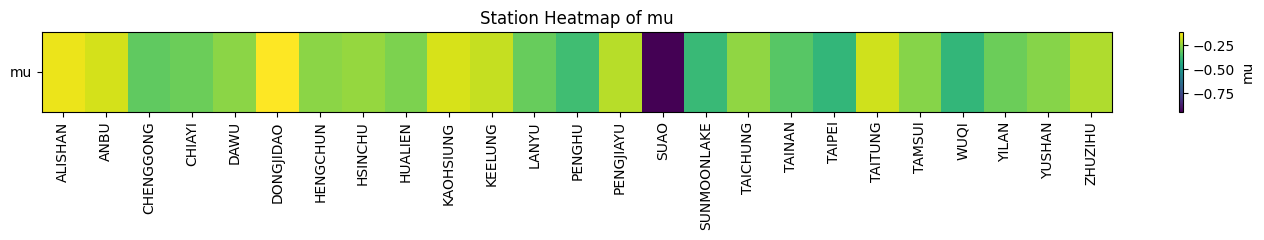

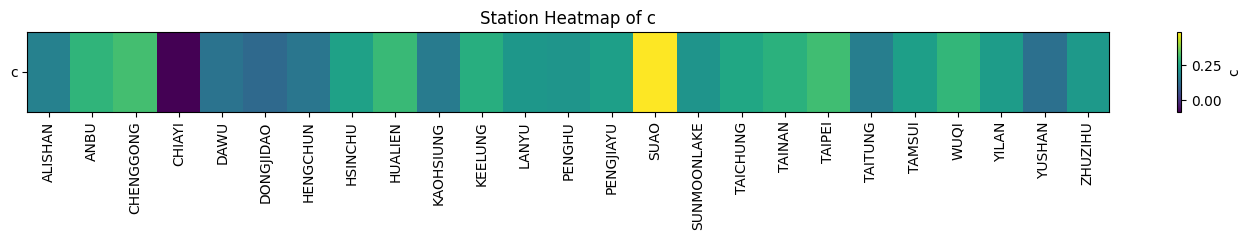

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

station_names = list(annual_max.columns[:len(preds)])

pred_df = pd.DataFrame({
    "station": station_names,
    "mu": preds[:, 0],
    "delta": preds[:, 1],
    "c": preds[:, 2],
})

# 轉成一列 heatmap
mu_heat = pred_df.set_index("station")[["mu"]].T
c_heat = pred_df.set_index("station")[["c"]].T

plt.figure(figsize=(14, 2.5))
plt.imshow(mu_heat, aspect="auto")
plt.xticks(range(len(mu_heat.columns)), mu_heat.columns, rotation=90)
plt.yticks([0], ["mu"])
plt.colorbar(label="mu")
plt.title("Station Heatmap of mu")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 2.5))
plt.imshow(c_heat, aspect="auto")
plt.xticks(range(len(c_heat.columns)), c_heat.columns, rotation=90)
plt.yticks([0], ["c"])
plt.colorbar(label="c")
plt.title("Station Heatmap of c")
plt.tight_layout()
plt.show()

In [6]:
coords = {
    "TAMSUI": (25.164888, 121.448906),
    "ANBU": (25.182587, 121.52973),
    "ZHUZIHU": (25.162079, 121.54455),
    "TAIPEI": (25.037659, 121.514854),
    "KEELUNG": (25.133314, 121.74048),
    "DONGJIDAO": (23.25695, 119.667465),
    "SU-AO": (24.596737, 121.85737),
    "YILAN": (24.763975, 121.75653),
    "HUALIEN": (23.975128, 121.61327),
    "PENGJIAYU": (25.627975, 122.07974),
    "PENGHU": (23.565502, 119.563095),
    "TAINAN": (22.993238, 120.20477),
    "KAOHSIUNG": (22.565992, 120.315735),
    "CHIAYI": (23.495926, 120.43291),
    "TAICHUNG": (24.145737, 120.684074),
    "HENGCHUN": (22.003897, 120.74634),
    "HSINCHU": (24.827852, 121.01422),
    "YUSHAN": (23.487614, 120.95952),
    "DAWU": (22.355675, 120.903786),
    "ALISHAN": (23.508207, 120.81324),
    "CHENGGONG": (23.097486, 121.37343),
    "LANYU": (22.036968, 121.55834),
    "SUN MOON LAKE": (23.881325, 120.90805),
    "TAITUNG": (22.75221, 121.15459),
    "WUQI": (24.256002, 120.523384),
}

coords_df = pd.DataFrame([
    {"station": k, "lat": v[0], "lon": v[1]}
    for k, v in coords.items()
])

coords_df.head()
plot_df = pred_df.merge(coords_df, on="station", how="inner")
plot_df

,station,mu,delta,c,lat,lon
0,ALISHAN,-0.142109,-1.186031,0.168237,23.508207,120.813240
1,ANBU,-0.169521,-1.630806,0.289228,25.182587,121.529730
2,CHENGGONG,-0.317484,-1.326132,0.317306,23.097486,121.373430
3,CHIAYI,-0.302829,-0.784699,-0.082403,23.495926,120.432910
4,DAWU,-0.259258,-1.001709,0.135035,22.355675,120.903786
5,DONGJIDAO,-0.117443,-1.220725,0.112743,23.256950,119.667465
6,HENGCHUN,-0.259020,-1.090986,0.140930,22.003897,120.746340
7,HSINCHU,-0.246971,-1.561513,0.243670,24.827852,121.014220
8,HUALIEN,-0.278793,-1.891938,0.303374,23.975128,121.613270
9,KAOHSIUNG,-0.166346,-0.847056,0.154375,22.565992,120.315735


## 畫 station heatmap

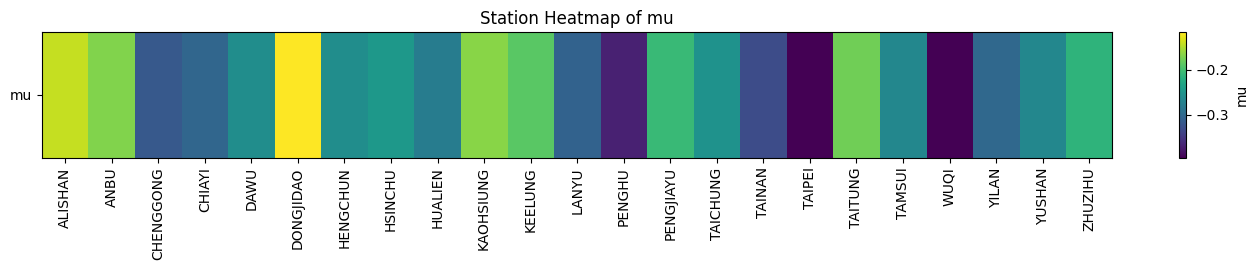

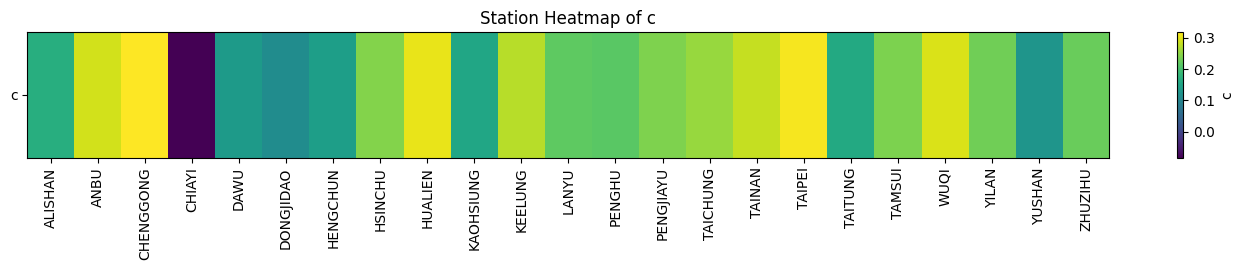

In [7]:
import matplotlib.pyplot as plt

mu_heat = plot_df.set_index("station")[["mu"]].T
c_heat = plot_df.set_index("station")[["c"]].T

plt.figure(figsize=(14, 2.8))
plt.imshow(mu_heat, aspect="auto")
plt.xticks(range(len(mu_heat.columns)), mu_heat.columns, rotation=90)
plt.yticks([0], ["mu"])
plt.colorbar(label="mu")
plt.title("Station Heatmap of mu")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 2.8))
plt.imshow(c_heat, aspect="auto")
plt.xticks(range(len(c_heat.columns)), c_heat.columns, rotation=90)
plt.yticks([0], ["c"])
plt.colorbar(label="c")
plt.title("Station Heatmap of c")
plt.tight_layout()
plt.show()

## 畫 $\mu$ spatial 分布

In [ ]:
# 使用測繪 shp
import geopandas as gpd

world = gpd.read_file(r"C:\Users\User.DESKTOP-4RV84M1\Downloads\ne_50m_admin_0_countries\ne_50m_admin_0_countries.shp")

taiwan = world[world["NAME"] == "Taiwan"]

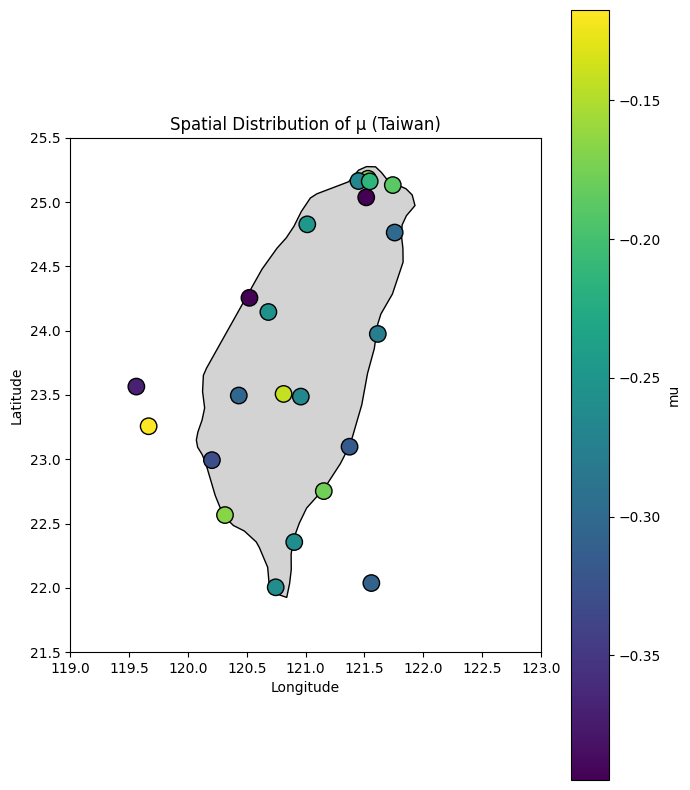

In [22]:
fig, ax = plt.subplots(figsize=(7, 8))

taiwan.plot(ax=ax, color="lightgray", edgecolor="black")

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df["mu"],
    s=140,
    cmap="viridis",
    edgecolor="black"
)

plt.colorbar(sc, ax=ax, label="mu")

ax.set_xlim(119, 123)
ax.set_ylim(21.5, 25.5)

ax.set_title("Spatial Distribution of μ (Taiwan)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

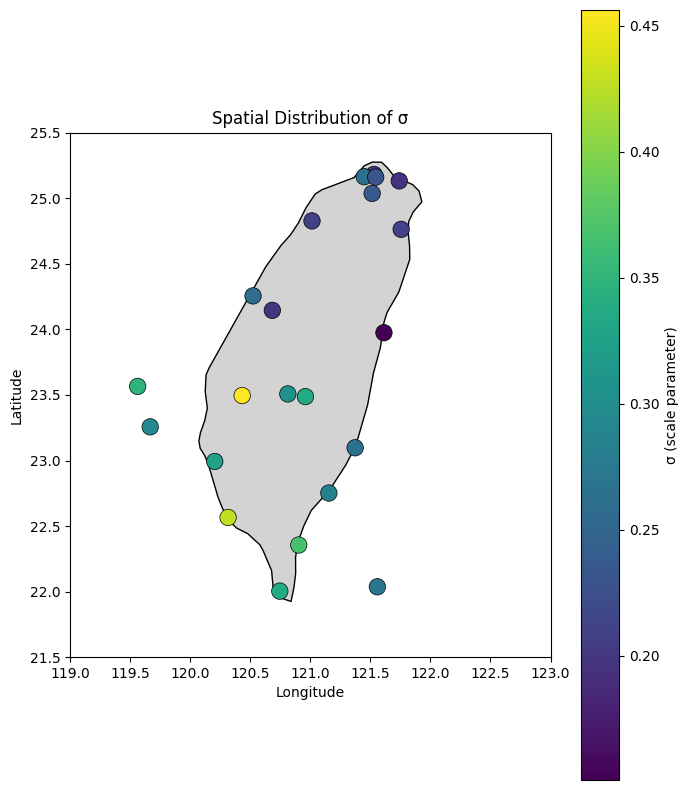

In [25]:
fig, ax = plt.subplots(figsize=(7, 8))

# 底圖
taiwan.plot(ax=ax, color="lightgray", edgecolor="black")

# σ（注意：如果你用的是 delta，要先轉）
sigma = np.exp(plot_df["delta"])  # ← 很重要

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=sigma,
    s=140,
    cmap="viridis",   # ← 單調色
    edgecolor="black",
    linewidth=0.5
)

plt.colorbar(sc, ax=ax, label="σ (scale parameter)")

ax.set_xlim(119, 123)
ax.set_ylim(21.5, 25.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial Distribution of σ")

plt.tight_layout()
plt.show()

## 畫 $xi$ spatial 分布

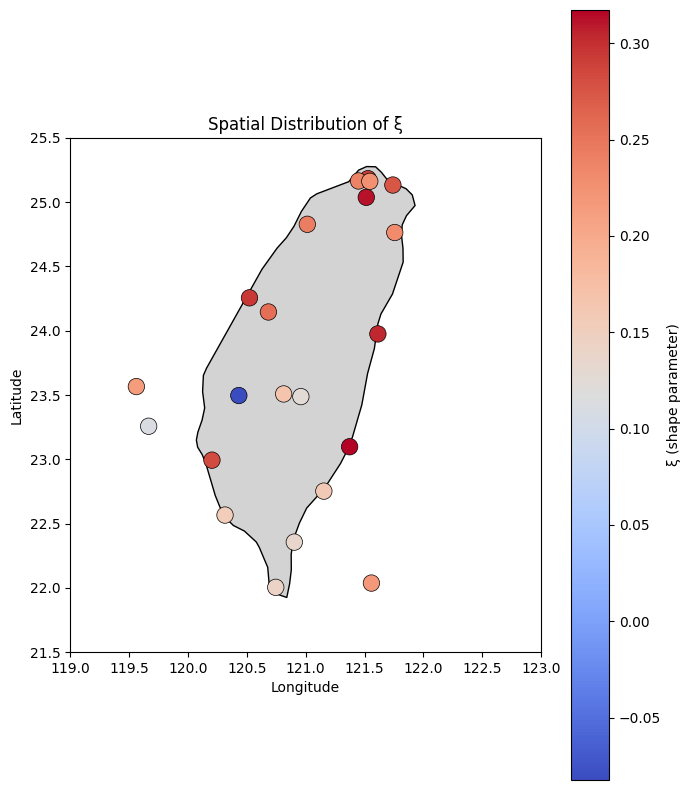

In [23]:
fig, ax = plt.subplots(figsize=(7, 8))

# 畫底圖
taiwan.plot(ax=ax, color="lightgray", edgecolor="black")

# 畫測站（ξ = c）
sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df["c"],
    s=140,
    cmap="coolwarm",   # ξ 建議用 diverging colormap（有正有負）
    edgecolor="black",
    linewidth=0.5
)

# colorbar
plt.colorbar(sc, ax=ax, label="ξ (shape parameter)")

# 限制範圍（只看台灣）
ax.set_xlim(119, 123)
ax.set_ylim(21.5, 25.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial Distribution of ξ")

plt.tight_layout()
plt.show()

## Bootstrap-NN 與 ML 比較

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

nn = pd.read_csv("nn_bootstrap_results.csv")
ml = pd.read_csv("mle_results.csv")

df = nn.merge(ml, on=["panel", "true_value", "rep"], how="inner")

df["ratio_mu"] = df["nn_width_mu"] / df["ml_width_mu"]
df["ratio_sigma"] = df["nn_width_sigma"] / df["ml_width_sigma"]
df["ratio_xi"] = df["nn_width_xi"] / df["ml_width_xi"]

print(df.head())

  panel  true_value  rep  nn_width_mu  nn_width_sigma  nn_width_xi  \
0    mu         1.0    0     2.199462        2.020198     0.157918   
1    mu         1.0    1     2.393185        1.933007     0.166876   
2    mu         1.0    2     2.291024        2.013975     0.171327   
3    mu         1.0    3     2.108166        1.857379     0.171342   
4    mu         1.0    4     2.302342        2.095912     0.165588   

   ml_width_mu  ml_width_sigma  ml_width_xi  ratio_mu  ratio_sigma  ratio_xi  
0     2.149297        1.692871     0.163287  1.023340     1.193356  0.967120  
1     2.124921        1.671343     0.135475  1.126246     1.156559  1.231786  
2     2.180772        1.743291     0.159100  1.050557     1.155272  1.076850  
3     1.988206        1.568085     0.153767  1.060336     1.184489  1.114302  
4     2.158159        1.687933     0.147895  1.066809     1.241703  1.119634  


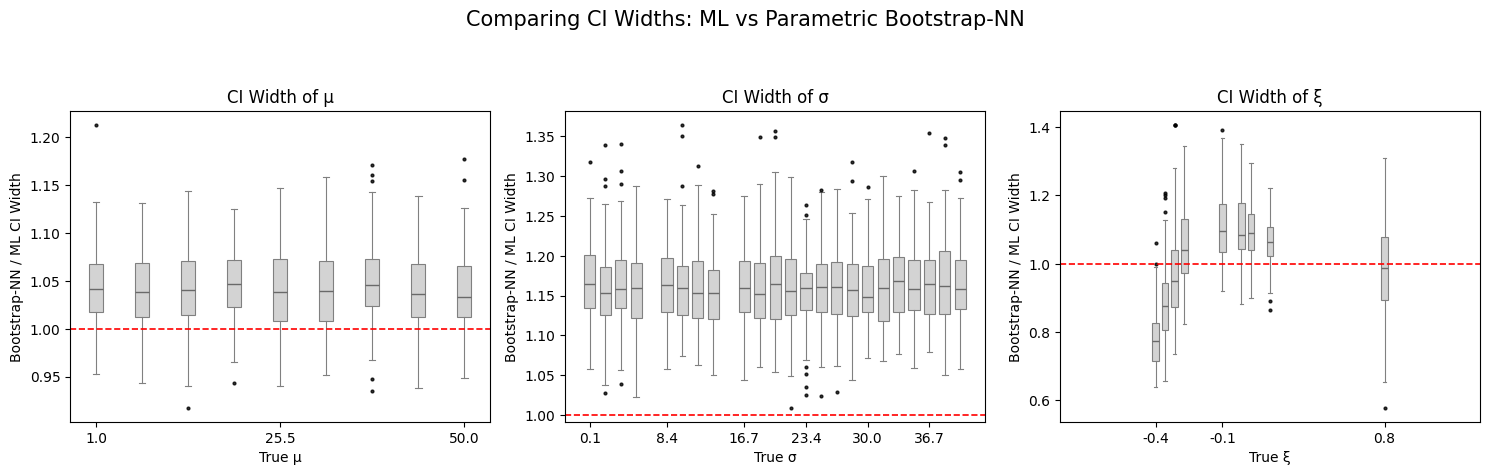

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle("Comparing CI Widths: ML vs Parametric Bootstrap-NN", fontsize=15)

panel_info = [
    ("mu", "ratio_mu", "CI Width of μ", "True μ"),
    ("sigma", "ratio_sigma", "CI Width of σ", "True σ"),
    ("xi", "ratio_xi", "CI Width of ξ", "True ξ"),
]

for ax, (panel, ratio_col, title, xlabel) in zip(axes, panel_info):
    sub = df[df["panel"] == panel].copy()

    # 避免浮點數排序怪掉
    sub["true_value_round"] = sub["true_value"].round(3)
    x_vals = np.sort(sub["true_value_round"].unique())

    box_data = [
        sub.loc[sub["true_value_round"] == x, ratio_col].dropna().values
        for x in x_vals
    ]

    # box 寬度依 panel 個別調整
    if panel == "mu":
        width = 1.8
        tick_step = 4
        fmt = lambda v: f"{v:.1f}"
    elif panel == "sigma":
        width = 1.2
        tick_step = 4
        fmt = lambda v: f"{v:.1f}"
    else:  # xi
        width = 0.035
        tick_step = 4
        fmt = lambda v: f"{v:.1f}"

    ax.boxplot(
        box_data,
        positions=x_vals,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="lightgray", color="gray", linewidth=0.8),
        medianprops=dict(color="dimgray", linewidth=1.0),
        whiskerprops=dict(color="gray", linewidth=0.8),
        capprops=dict(color="gray", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=2,
            markerfacecolor="black",
            markeredgecolor="black",
            alpha=0.8
        )
    )

    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Bootstrap-NN / ML CI Width")

    # 只顯示部分 x 軸刻度，不然太擠
    tick_vals = x_vals[::tick_step]
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([fmt(v) for v in tick_vals], rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 對三個參數分別做 kriging 後 map 出來 

假設

$$
\mu(s)
=
x(s)^\top \beta_\mu + W_\mu(s)
$$

$$
\log\sigma(s)
=
x(s)^\top \beta_\sigma + W_\sigma(s)
$$

$$
\xi(s)
=
x(s)^\top \beta_\xi + W_\xi(s)
$$

其中

$$W_\mu(s) \sim GP(0, C_\mu(h))$$

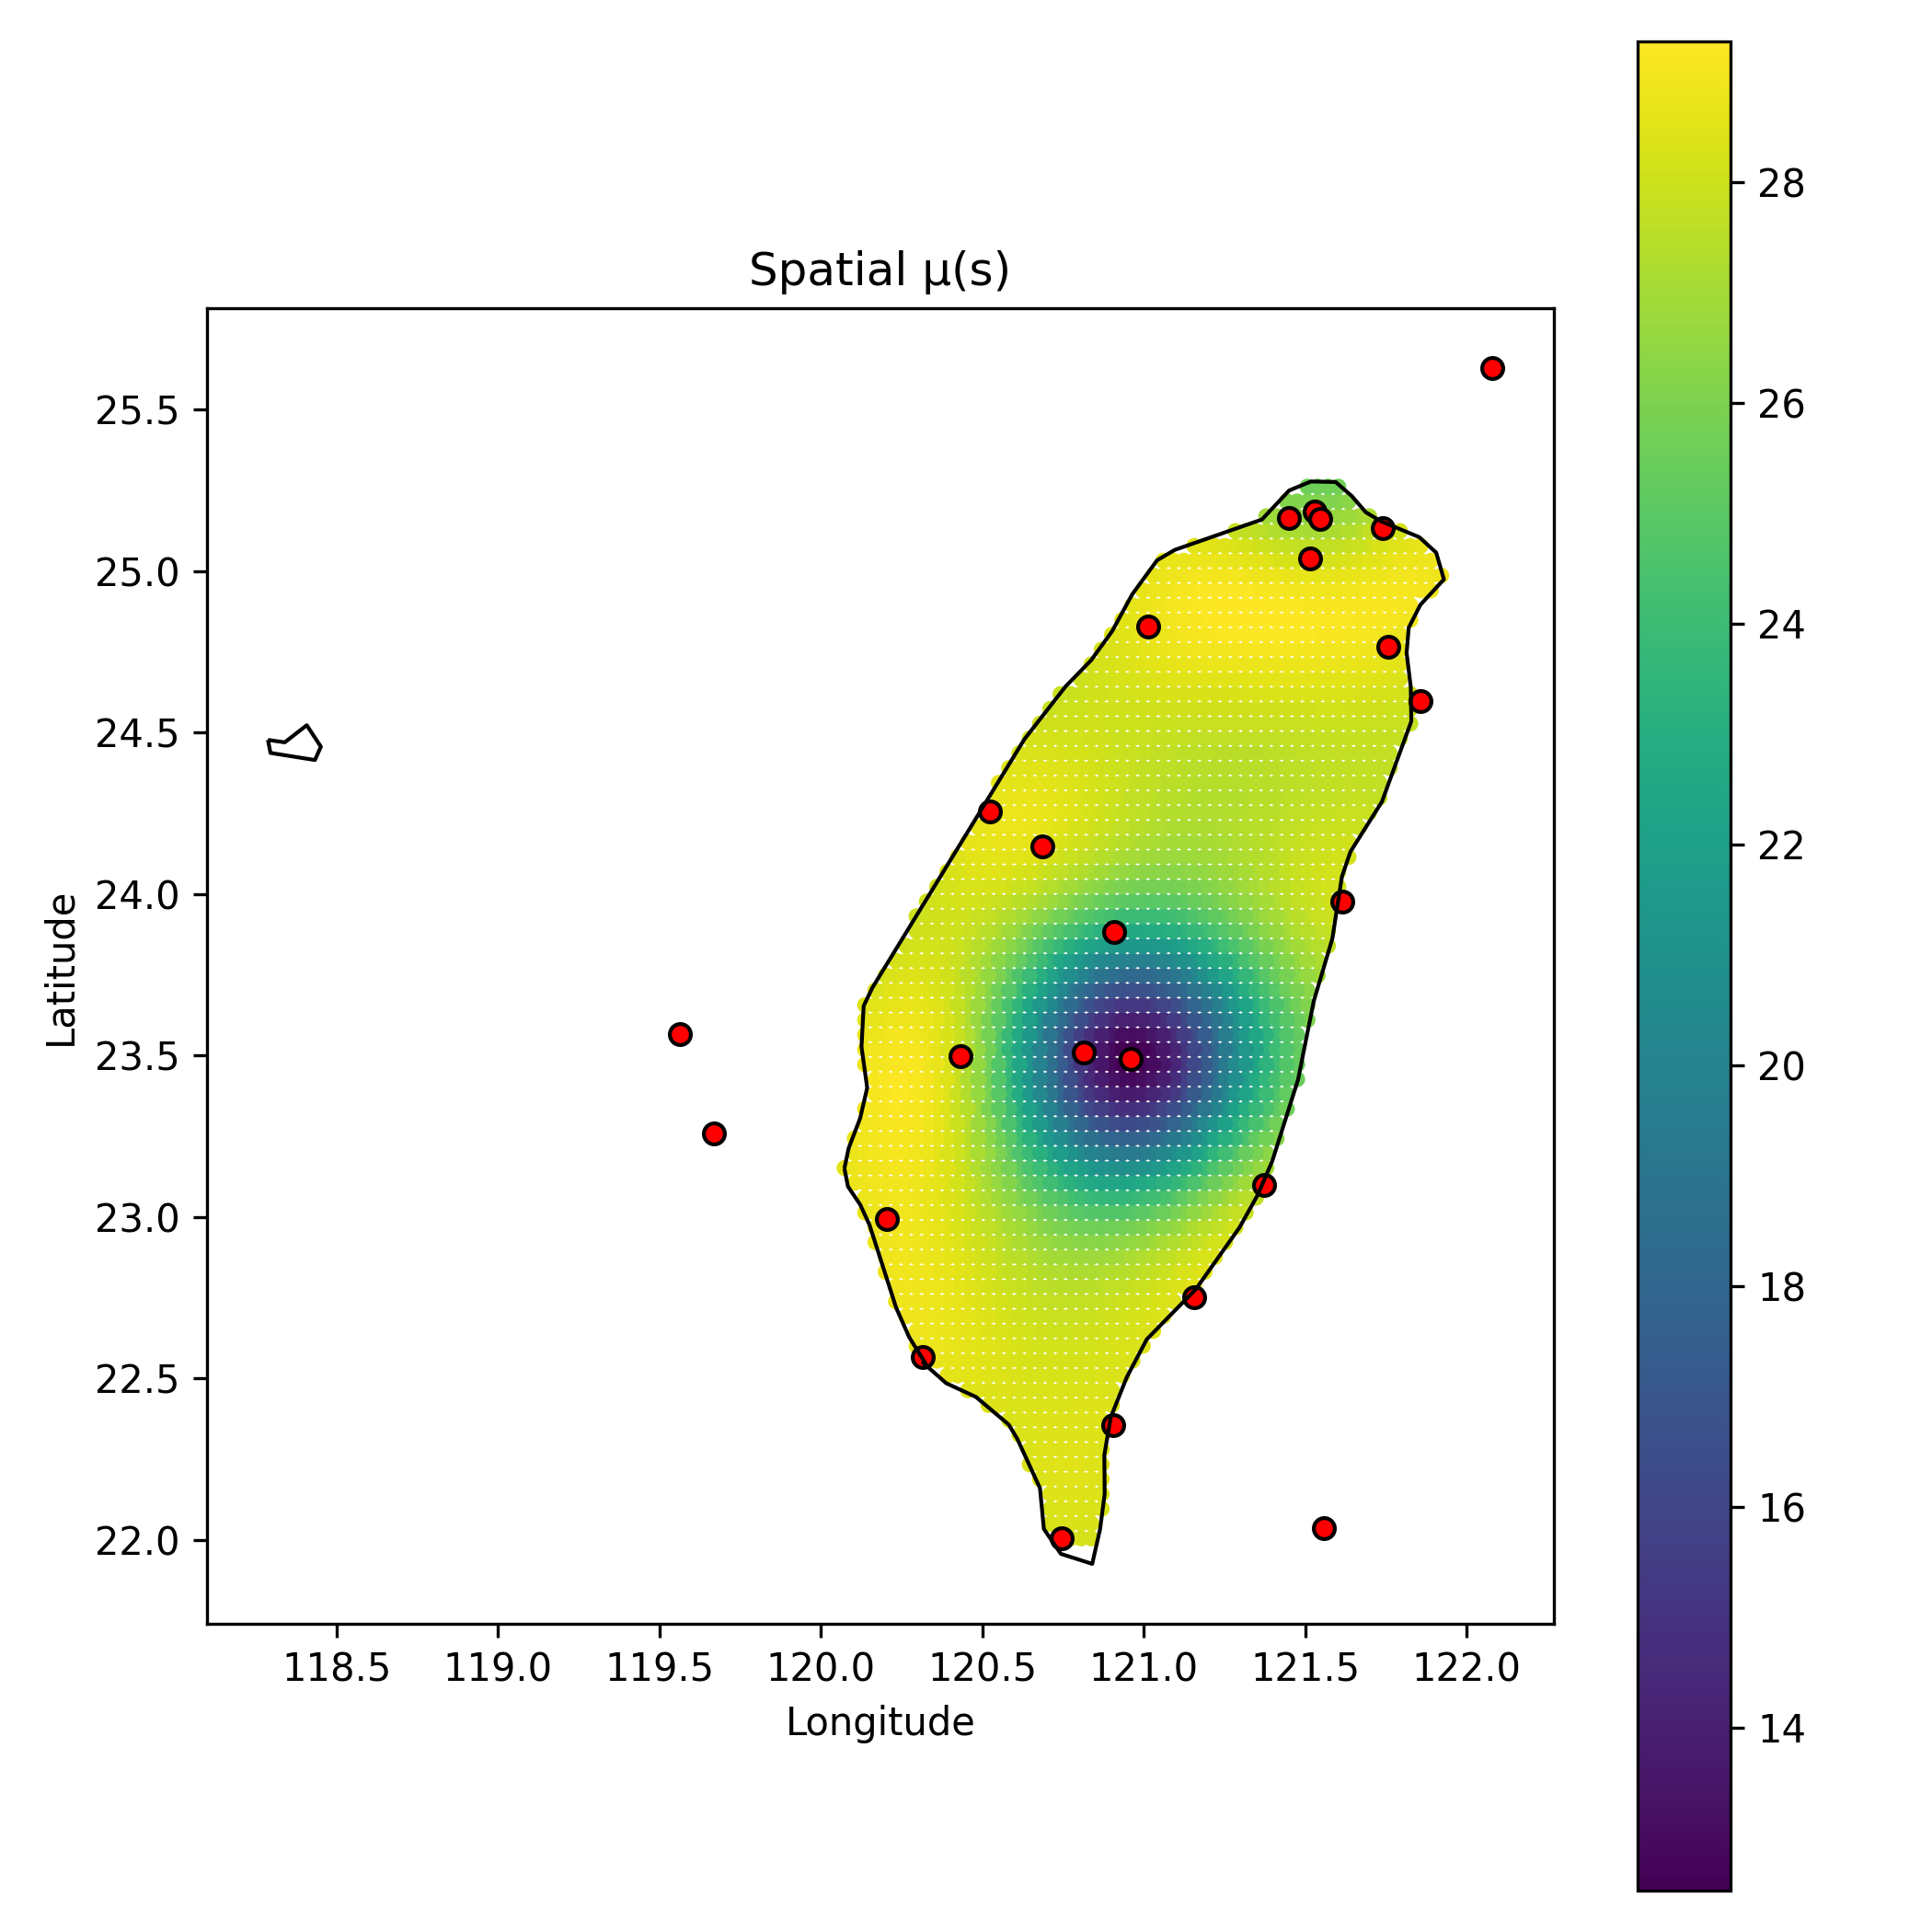

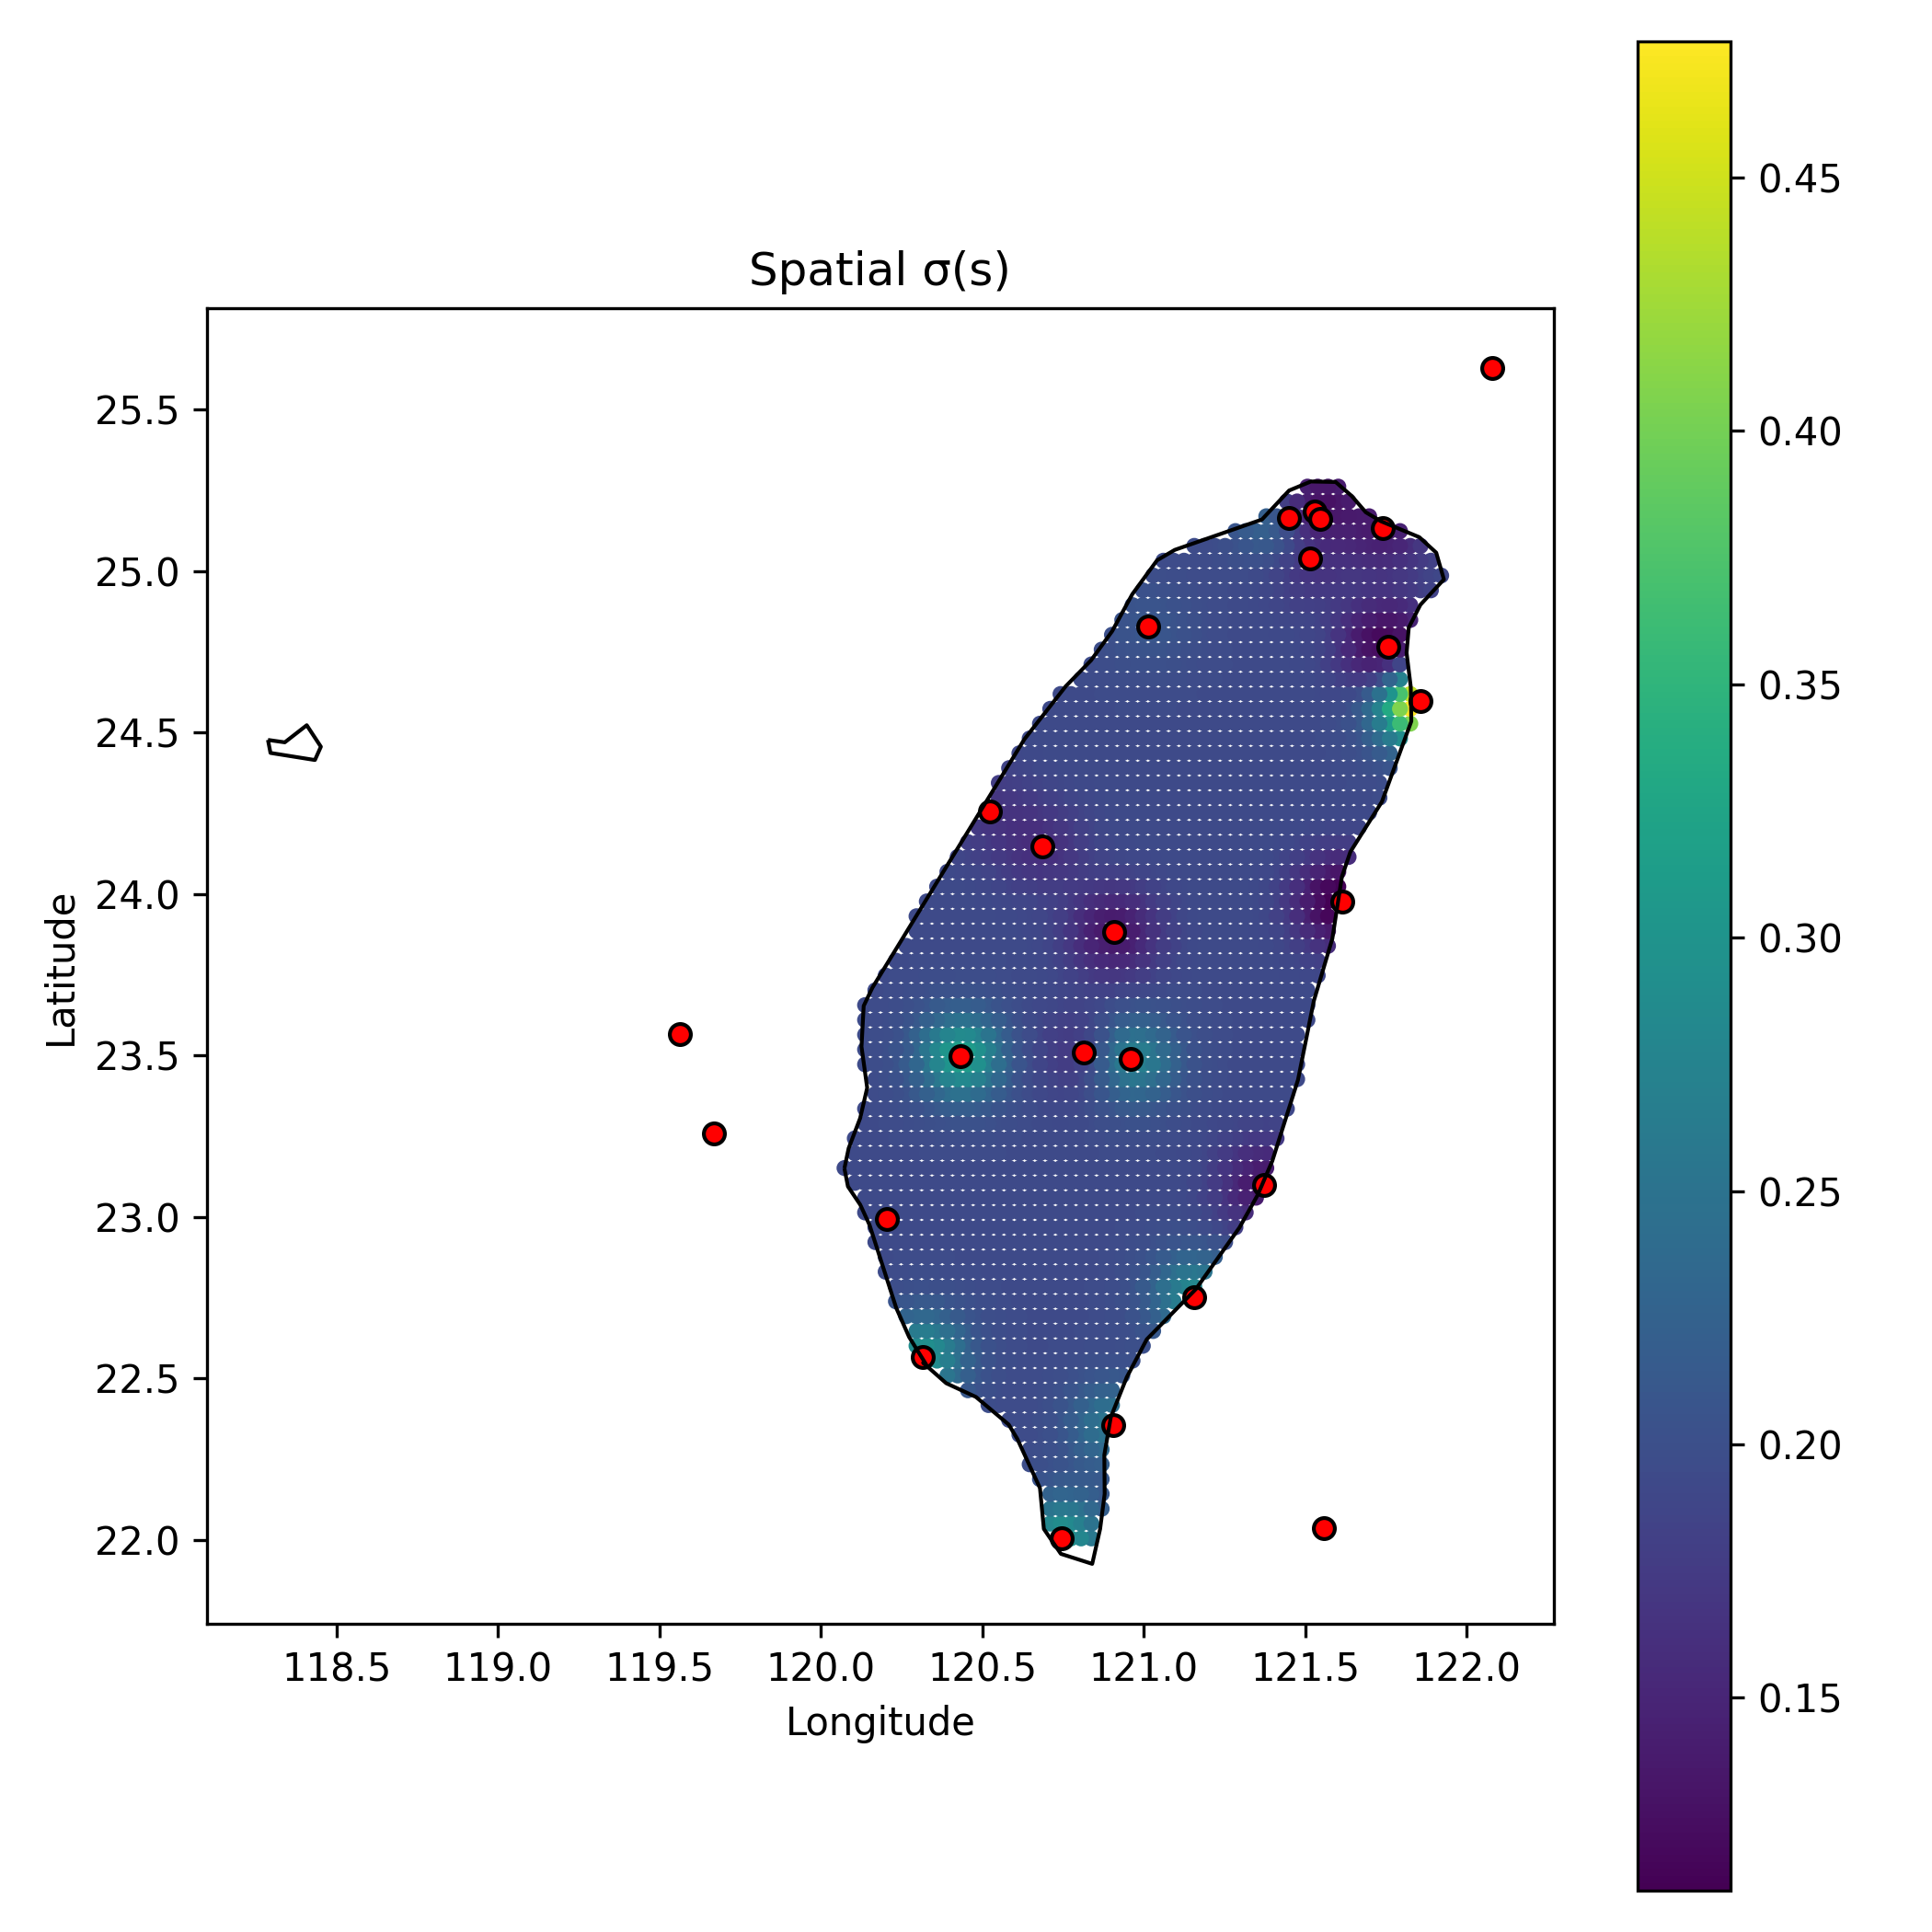

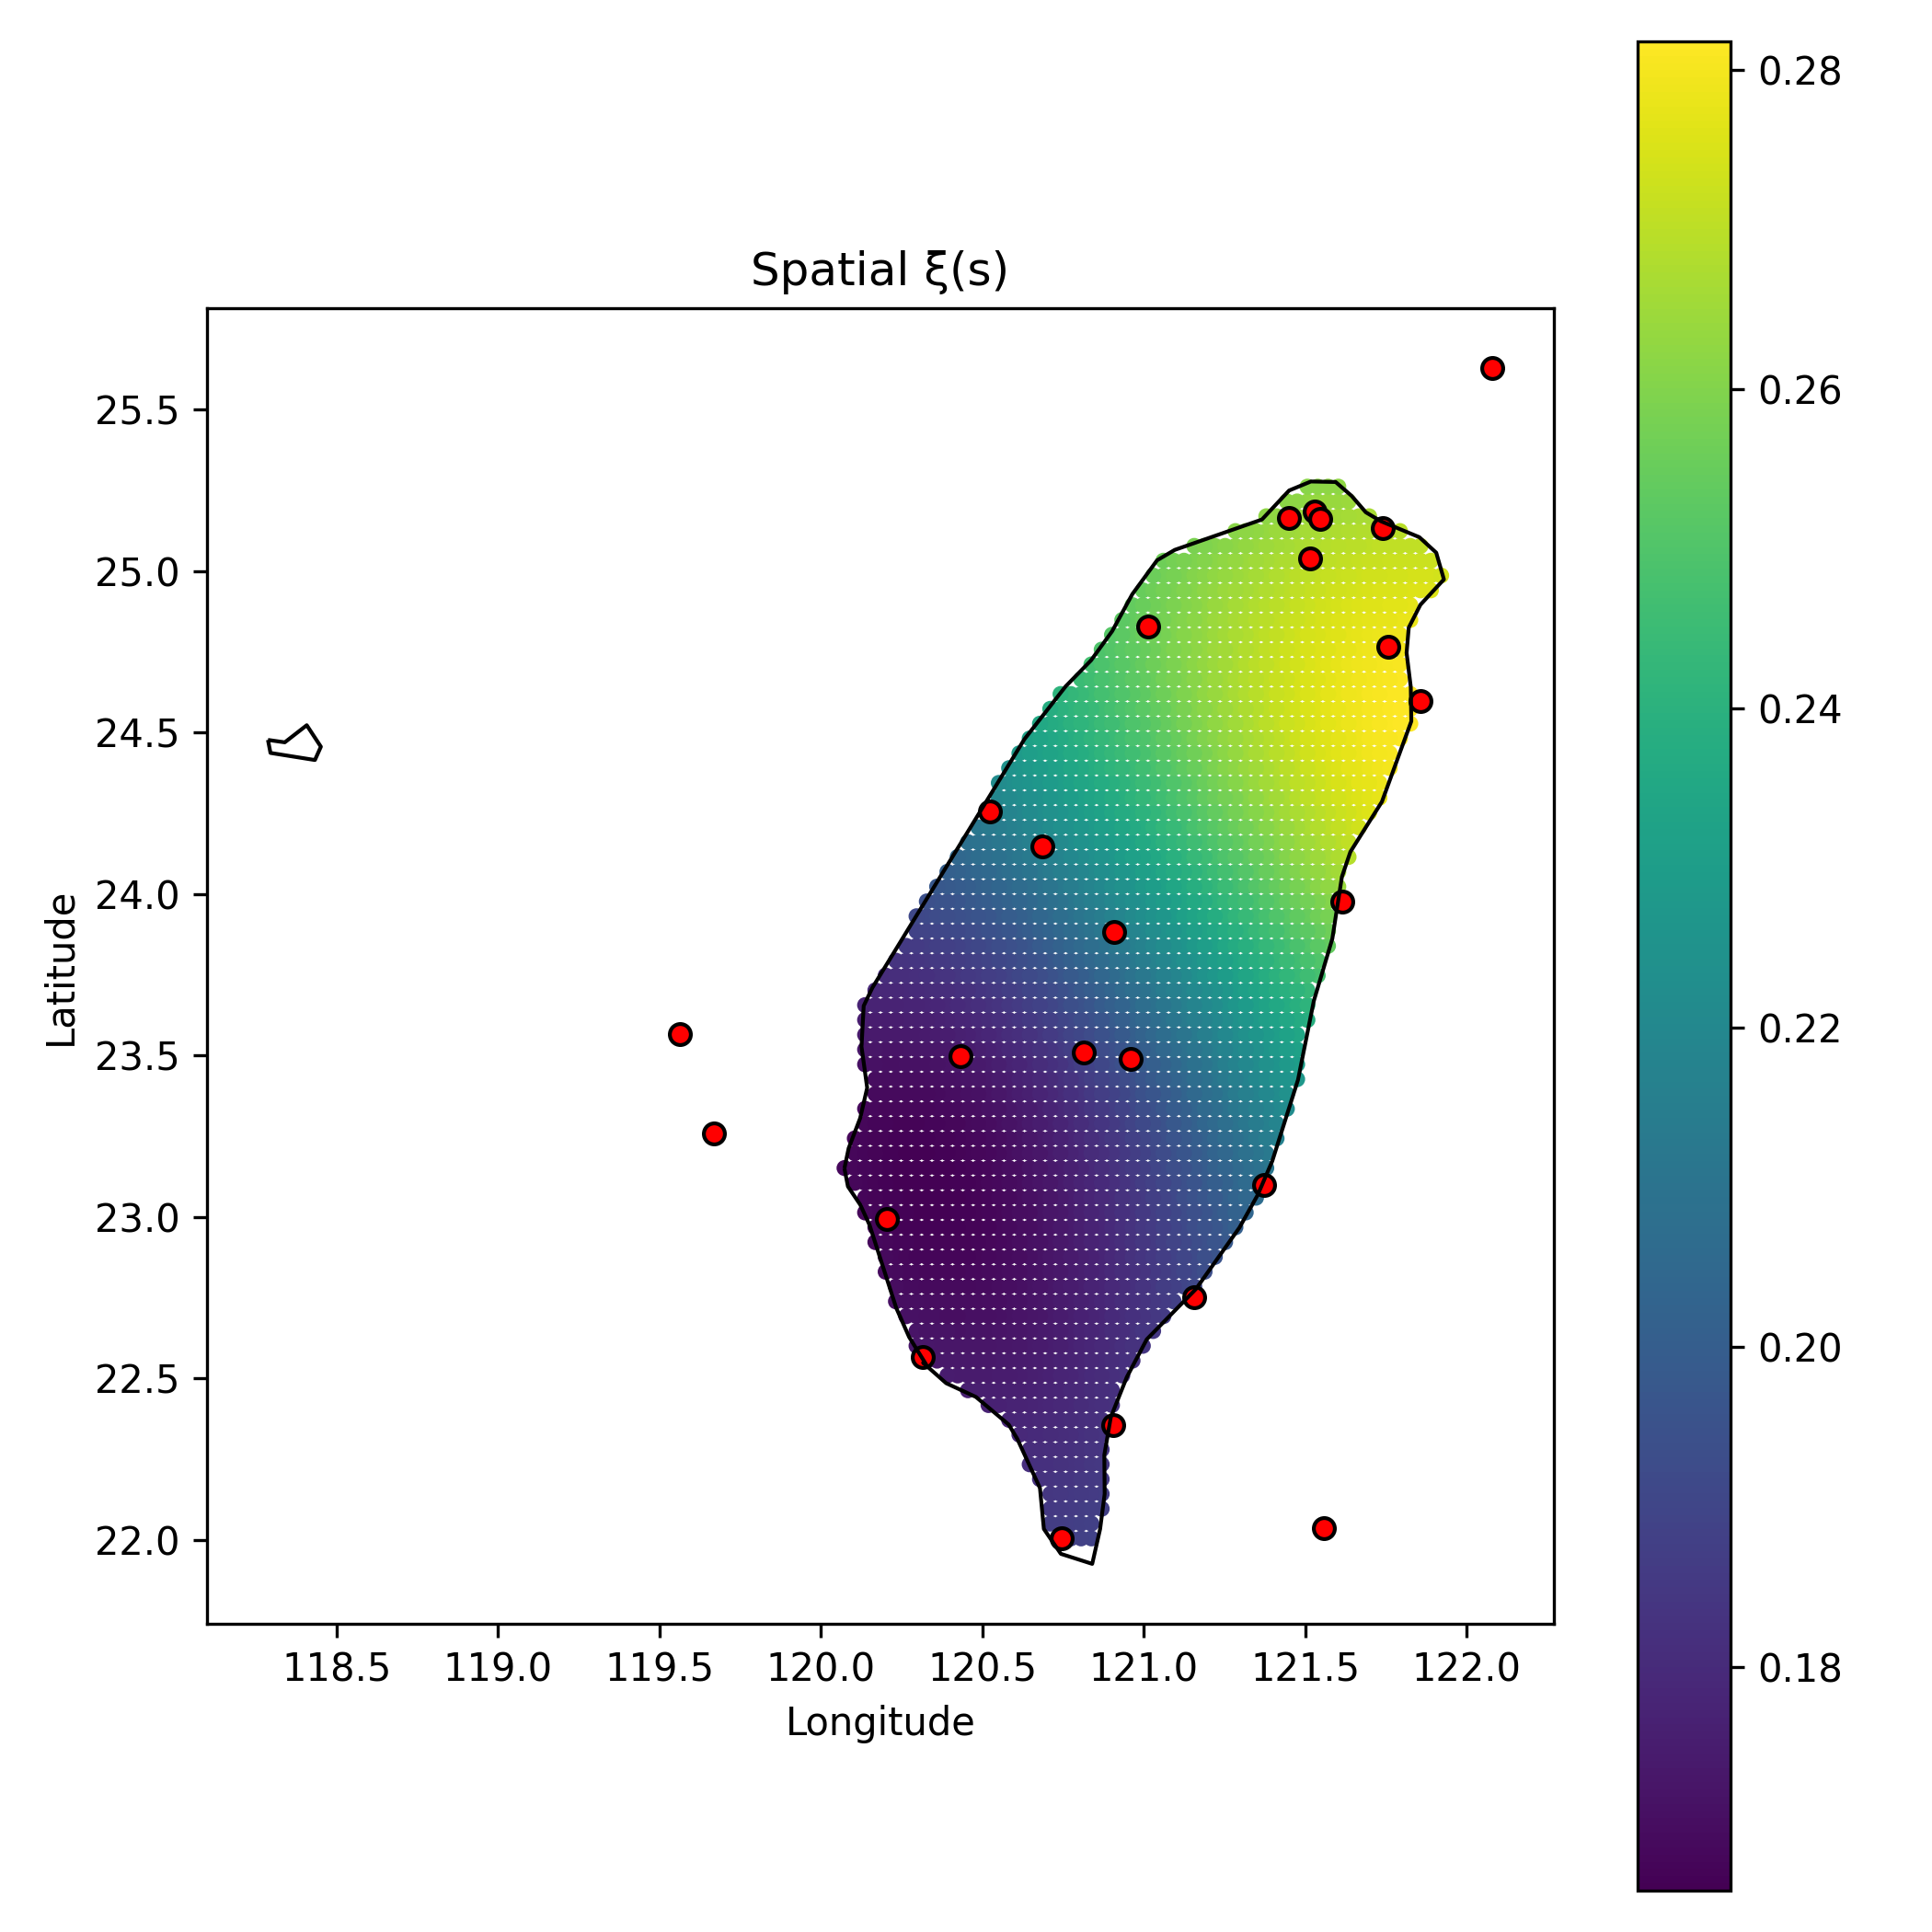

In [11]:
import os
from IPython.display import Image, display

os.system("python ../src/plot_gev_maps.py")

display(Image(filename="../results/figures/map_mu.png"))
display(Image(filename="../results/figures/map_sigma.png"))
display(Image(filename="../results/figures/map_xi.png"))

## 計算 return_leval_surface

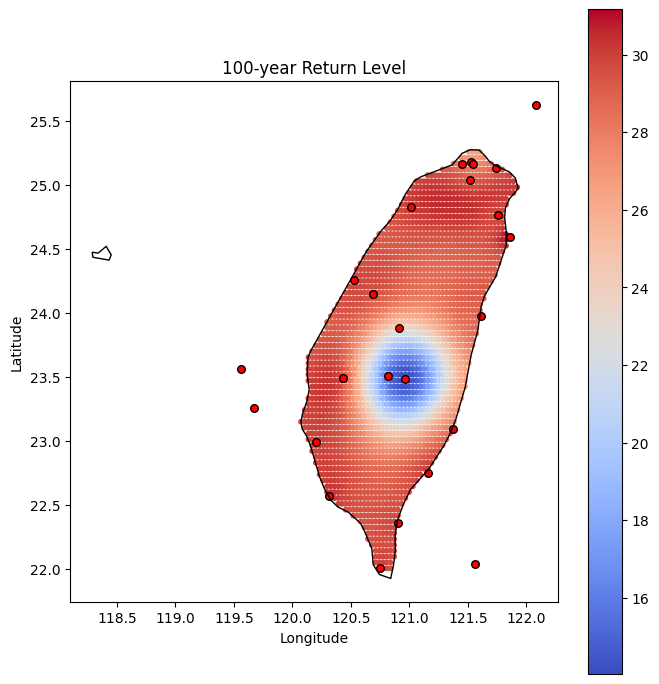

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# 1. 執行 return level 計算
os.system("python ../src/compute_return_level.py") 

# 2. 讀資料
grid = pd.read_csv("../data/processed/grid_return_level.csv")
stations = pd.read_csv("../data/processed/station_gev_params_with_loc.csv")

# 3. 讀 Taiwan shapefile
world = gpd.read_file(r"C:\Users\User.DESKTOP-4RV84M1\Downloads\ne_50m_admin_0_countries\ne_50m_admin_0_countries.shp")
taiwan = world[world["NAME"].str.contains("Taiwan")]

# 4. grid → GeoDataFrame

geometry = [Point(xy) for xy in zip(grid["lon"], grid["lat"])]
gdf = gpd.GeoDataFrame(grid, geometry=geometry, crs="EPSG:4326")

gdf_clipped = gpd.clip(gdf, taiwan)

# 5. stations

station_geom = [Point(xy) for xy in zip(stations["lon"], stations["lat"])]
stations_gdf = gpd.GeoDataFrame(stations, geometry=station_geom, crs="EPSG:4326")

# 6. 畫 Return Level Map
fig, ax = plt.subplots(figsize=(7, 7))

taiwan.boundary.plot(ax=ax, color="black", linewidth=1)

gdf_clipped.plot(
    column="z_T",
    ax=ax,
    cmap="coolwarm",
    markersize=10,
    legend=True
)

stations_gdf.plot(
    ax=ax,
    color="red",
    markersize=30,
    edgecolor="black"
)

ax.set_title("100-year Return Level")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()